# plot ejemplo gam

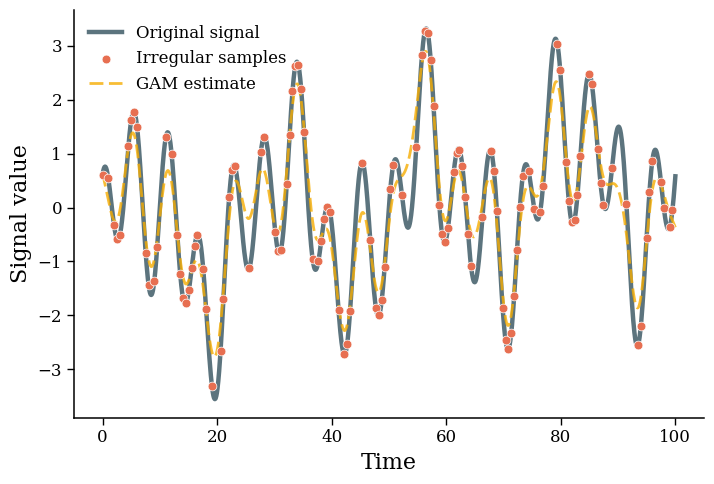

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

# =========================================================
# STYLE (paper-like)
# =========================================================

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.linewidth": 1.1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 1,
    "ytick.major.width": 1,
})

# =========================================================
# GENERATE ORIGINAL CURVE
# =========================================================

np.random.seed(42)

x_true = np.linspace(0, 100, 2000)

# complex fluctuating signal
y_true = (
    1.2 * np.sin(x_true / 4)
    + 0.7 * np.sin(x_true / 1.7)
    + 1.35 * np.cos(x_true / 0.9)
    + 0.015 * (x_true - 50)
)

# =========================================================
# NON-EQUIDISTANT SAMPLES
# =========================================================

# irregular sampling
x_sample = np.sort(
    np.random.choice(
        np.linspace(0, 100, 200),
        size=120,
        replace=False
    )
)

# interpolate original signal + small noise
y_sample = np.interp(x_sample, x_true, y_true)
y_sample += np.random.normal(0, 0, len(y_sample))

# =========================================================
# GAM FIT
# =========================================================

gam = LinearGAM(
    s(0, n_splines=len(y_sample), lam=0.8)
).fit(x_sample[:, None], y_sample)

y_gam = gam.predict(x_true)

# =========================================================
# COLORS
# =========================================================

color_true = "#1b4965"
color_points = "#ca6702"
color_gam = "#2a9d8f"

color_true = "#1b4965"     # azul profundo
color_points = "#b56576"   # dusty rose
color_gam = "#6d597a"      # muted purple

color_true = "#264653"     # dark teal
color_points = "#e76f51"   # coral
color_gam = "#a1a94a" 
color_gam ="#dbb314"  
color_gam ="#f6ad02"  # sage green

# color_true = "#003049"     # navy
# color_points = "#f77f00"   # orange
# color_gam = "#8ab17d"      # dark red
# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(7.3, 5))

# original curve
ax.plot(
    x_true,
    y_true,
    color=color_true,
    linewidth=3.2,
    label="Original signal",
    alpha=0.75
)

# sampled points
ax.scatter(
    x_sample,
    y_sample,
    s=40,
    color=color_points,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
    label="Irregular samples"
)

# GAM estimate
ax.plot(
    x_true,
    y_gam,
    color=color_gam,
    linewidth=2,
    linestyle=(0, (5, 2)),
    label="GAM estimate",
    alpha=0.8
)

# =========================================================
# AXES
# =========================================================

ax.set_xlabel("Time",  fontsize=16)
ax.set_ylabel("Signal value", fontsize=16)

# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# cleaner ticks
ax.tick_params(length=5)

# legend
ax.legend(
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Plots enlaces negativos

## lectura datos

In [52]:
import pandas as pd
import pickle as pkl

df_basa_full=pd.read_csv('basa_original.csv')
df_gg_full=pd.read_csv('gg_original.csv')
df_gg_pollen_full=pd.read_csv('gg_original_pollen.csv')
df_gg_2=pd.read_csv('bale_pollen.csv')

non_aquatic_species = 'Abies,Pinus,Juniperus,Taxus,Betula,Corylus,Alnus,Carpinus,Salix,Ulmus,Populus,Acer,Fraxinus,Fagus,Tilia,Juglans,Castanea,Quercus caducifolio,Quercus perennifolio,Pistacia,Rhamnus,Phillyrea,Buxus,Sambucus,Viburnum,Sanguisorba,Tamarix,Thymelaeaceae,Ephedra distachya,Ephedra fragilis,Ericaceae,Hereda helix,Ilex aquifolium,Viscum album,Lonicera,Vitis,Oleaceae,Myrtus,Olea,Poaceae,Lygeum spartum,Artemisia,Cichorioideae,Asteroideae,Cardueae,Rubiaceae,Centaurea,Chenopodiaceae,Caryophyllaceae,Plantago,Brassicaceae,Saxifragaceae,Fabaceae,Genista,Lotus type,Trifolium type,Rosaceae,Ribes,Boraginaceae,Sedum,Helianthemum,Lamiaceae,Urticaceae,Rumex,Berberidaceae,Euphorbiaceae,Primulaceae,Scrophulariaceae,Papaver,Campanulaceae,Convolvulaceae,Liliaceae,Iridaceae,Crassulaceae,Ranunculaceae,Cistaceae,Galium,Apiaceae,Valerianaceae,Cerealia type,Polygonaceae,Ranunculus'

species_mapping = {
        "Dec_Querc": "Quercus caducifolio",
        "Ever_Querc": "Quercus perennifolio",
        "Ephedra dist": "Ephedra distachya",
        "Ephedra frag": "Ephedra fragilis",
        "Lygeum": "Lygeum spartum",
        "Cicho": "Cichorioideae",
        "Astroi": "Asteroideae",
        "Carduaceae": "Cardueae",
        "Rubiac": "Rubiaceae",
        "Chenopo": "Chenopodiaceae",
        "Caryphy": "Caryophyllaceae",
        "Brassicac": "Brassicaceae",
        "Saxifrag": "Saxifragaceae",
        "Boraginac": "Boraginaceae",
        "Helianthem": "Helianthemum",
        "Euphorbiac": "Euphorbiaceae",
        "Primulac": "Primulaceae",
        "Scrophulari": "Scrophulariaceae",
        "Campanulac": "Campanulaceae",
        "Valerian": "Valerianaceae",
        "Cerealia": "Cerealia type",
        "Polygon": "Polygonaceae"
    }

df_basa_full = df_basa_full.rename(columns=species_mapping)

non_aquatic_species = [s.strip() for s in non_aquatic_species.split(',')]
df_bas = df_basa_full[
    list(df_basa_full.columns[:8]) +
    [c for c in df_basa_full.columns[8:] if c in non_aquatic_species]
]

myspecies = 'Alchemilla,Chenopodiaceae,Artemisia,Cichoroideae,Asteroideae,Carduus,Asteraceae,Vernonia,Polygonum,Tribulus,Galium,Brassicaceae,Caryophylaceae,Swertia,Senecio,Erica,Hypericum,Anthospermum,Cerastium,Apiaceae,Podocarpus,Euclea,Hagenia,Juniperus,Myrsine,Rapanea,Rosa,Schefflera,Brucea,Sapotaceae,Iridaceae,Anthyllis,Maytenus,Buxus,Psydrax,Celastraceae,Celtis,Dodonaea,Ekebergia,Ephedra,Clematis,Myrica,Hypoestes,Ziziphus,Acanthus,Allophylus,Acacia,Combretum,Commiphora,Cussonia,Dobera,Lannea,Macaranga,Olea,Jasminum,Rhus,Securinega,Teclea,Zanthoxylum,Cassia,Capparidaceae,Acalypha,Euphorbia,Euphorbiacea,Phyllantus,Tamarindus,Alchornea,Aloe,Asphodellus,Leguminosae,Rubiaceae,Blepharis,Justicia,Heliotropium,Kohautia,Indigofera,Lamiaceae,Cerealia,Plantago,Planceolata,Poaceae,Rumex,Solanum,Urticaceae,Ricinus,Saussurea'.replace(' ','_').split(',')

df_gg_prov=df_gg_pollen_full[
    [c for c in df_gg_pollen_full.columns if c in myspecies]
]


#unir los dos df
df_gg=pd.concat([df_gg_full, df_gg_prov], axis=1)

#renombrar columna "ka.BP" a "cal BP"
df_gg.rename(columns={"ka.BP": "cal BP"}, inplace=True)
df_gg_2.rename(columns={"kaBP": "cal BP"}, inplace=True)


df_mos_full = pkl.load(open('dataset_moossee.pkl','rb')).reset_index()


df_mos_full
df_mos=df_mos_full.copy()
#renombrar columna name
df_mos.rename(columns={'age':'cal BP'}, inplace=True)


C:\Users\anica\AppData\Local\Temp\ipykernel_22944\3913203696.py:59: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df_mos_full = pkl.load(open('dataset_moossee.pkl','rb')).reset_index()


In [59]:
ABUNDANCIA_MINIMA=0.5
MIN_PRESENCIA=2.5

def es_serie_valida(serie):
    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)
    return (serie > 0).sum() >= MIN_PRESENCIA 

especies_bsm=df_bas.columns[
        df_bas.columns.get_loc('Abies'):
    ]

especies_gg= myspecies

especies_mos=df_mos.columns[
        df_mos.columns.get_loc('Alnus'):
    ]


In [63]:
import numpy as np
import pickle

# -----------------------------------
# CONFIGURACIÓN VENTANAS
# -----------------------------------
WINDOWS = {
    "w1": (9798, 6253),
    "w2": (6253, 3842),
    "w3": (3842, -57)
}


BSM_WINDOWS = {
    "w1": "bsm_w1_counts.pkl",
    "w2": "bsm_w2_counts.pkl",
    "w3": "bsm_w3_counts.pkl"
}

# -----------------------------------
# FUNCIONES
# -----------------------------------

def extraer_ventana(df, cal_min, cal_max):

    mask = (
        (df["cal BP"] >= min(cal_min, cal_max)) &
        (df["cal BP"] <= max(cal_min, cal_max))
    )

    return df[mask].copy().reset_index(drop=True)


def es_serie_valida(serie):

    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)

    return (serie > 0).sum() >= MIN_PRESENCIA


def obtener_especies_validas(df_ventana, columnas_especies):

    especies_validas = [
        col for col in columnas_especies
        if es_serie_valida(df_ventana[col])
    ]

    return especies_validas


def filtrar_resultado(resultado, especies_validas):

    especies_originales = resultado['especies']

    indices_validos = [
        i for i, esp in enumerate(especies_originales)
        if esp in especies_validas
    ]

    especies_filtradas = [
        especies_originales[i]
        for i in indices_validos
    ]

    print("\nANTES:")
    print(len(especies_originales))

    print("\nDESPUÉS:")
    print(len(especies_filtradas))

    resultado_filtrado = {
        'especies': especies_filtradas
    }

    for clave in [
        'matriz_coeficientes',
        'matriz_significancia',
        'matriz_pvalores'
    ]:

        matriz = resultado[clave]

        resultado_filtrado[clave] = matriz[
            np.ix_(indices_validos, indices_validos)
        ]

    return resultado_filtrado


# -----------------------------------
# PROCESAR TODO
# -----------------------------------

resultados_filtrados = {}

df_bas_2 = df_bas.sort_values("cal BP", ascending=False).reset_index(drop=True)


for ventana, fichero in BSM_WINDOWS.items():

    print(f"\n########## {ventana} ##########")

    # límites temporales
    cal_min, cal_max = WINDOWS[ventana]

    # extraer solo esa ventana temporal
    df_ventana = extraer_ventana(df_bas_2, cal_min, cal_max)

    # calcular especies válidas SOLO en esta ventana
    especies_validas = obtener_especies_validas(
        df_ventana,
        especies_bsm
    )

    print("\nEspecies válidas:")
    #print(especies_validas)

    # cargar pkl
    with open(fichero, "rb") as f:
        resultado = pickle.load(f)

    # filtrar matrices
    resultado_filtrado = filtrar_resultado(
        resultado,
        especies_validas
    )

    resultados_filtrados[ventana] = resultado_filtrado

    # guardar
    nuevo_nombre = fichero.replace(
        ".pkl",
        "_filtrado.pkl"
    )

    with open(nuevo_nombre, "wb") as f:
        pickle.dump(resultado_filtrado, f)

    print(f"\nGuardado: {nuevo_nombre}")


########## w1 ##########

Especies válidas:

ANTES:
64

DESPUÉS:
63

Guardado: bsm_w1_counts_filtrado.pkl

########## w2 ##########

Especies válidas:

ANTES:
61

DESPUÉS:
54

Guardado: bsm_w2_counts_filtrado.pkl

########## w3 ##########

Especies válidas:

ANTES:
71

DESPUÉS:
69

Guardado: bsm_w3_counts_filtrado.pkl


In [56]:
import numpy as np
import pickle

# -----------------------------------
# CONFIGURACIÓN VENTANAS
# -----------------------------------
WINDOWS = {
    "w1": (0, 56),
    "w2": (57, 149),
    "w3": (150, 249),
    "w4": (250, 300)
}


GG_WINDOWS = {
    "w1": "gg_w1_counts.pkl",
    "w2": "gg_w2_counts.pkl",
    "w3": "gg_w3_counts.pkl",
    "w4": "gg_w4_counts.pkl",
}

# -----------------------------------
# FUNCIONES
# -----------------------------------

def extraer_ventana(df, idx_min, idx_max):
    return df.iloc[idx_min:idx_max + 1].copy().reset_index(drop=True)


def es_serie_valida(serie):

    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)

    return (serie > 0).sum() >= MIN_PRESENCIA


def obtener_especies_validas(df_ventana, columnas_especies):

    especies_validas = [
        col for col in columnas_especies
        if es_serie_valida(df_ventana[col])
    ]

    return especies_validas


def filtrar_resultado(resultado, especies_validas):

    especies_originales = resultado['especies']

    indices_validos = [
        i for i, esp in enumerate(especies_originales)
        if esp in especies_validas
    ]

    especies_filtradas = [
        especies_originales[i]
        for i in indices_validos
    ]

    print("\nANTES:")
    print(len(especies_originales))

    print("\nDESPUÉS:")
    print(len(especies_filtradas))

    resultado_filtrado = {
        'especies': especies_filtradas
    }

    for clave in [
        'matriz_coeficientes',
        'matriz_significancia',
        'matriz_pvalores'
    ]:

        matriz = resultado[clave]

        resultado_filtrado[clave] = matriz[
            np.ix_(indices_validos, indices_validos)
        ]

    return resultado_filtrado


# -----------------------------------
# PROCESAR TODO
# -----------------------------------

resultados_filtrados = {}
df_gg_3 = df_gg_2.sort_values("cal BP", ascending=False).reset_index(drop=True)


for ventana, fichero in GG_WINDOWS.items():

    print(f"\n########## {ventana} ##########")

    # límites temporales
    cal_min, cal_max = WINDOWS[ventana]

    # extraer solo esa ventana temporal
    df_ventana = extraer_ventana(df_gg_3, cal_min, cal_max)

    # calcular especies válidas SOLO en esta ventana
    especies_validas = obtener_especies_validas(
        df_ventana,
        especies_gg
    )

    print("\nEspecies válidas:")
    #print(especies_validas)

    # cargar pkl
    with open(fichero, "rb") as f:
        resultado = pickle.load(f)

    # filtrar matrices
    resultado_filtrado = filtrar_resultado(
        resultado,
        especies_validas
    )

    resultados_filtrados[ventana] = resultado_filtrado

    # guardar
    nuevo_nombre = fichero.replace(
        ".pkl",
        "_filtrado.pkl"
    )

    with open(nuevo_nombre, "wb") as f:
        pickle.dump(resultado_filtrado, f)

    print(f"\nGuardado: {nuevo_nombre}")


########## w1 ##########

Especies válidas:

ANTES:
83

DESPUÉS:
46

Guardado: gg_w1_counts_filtrado.pkl

########## w2 ##########

Especies válidas:

ANTES:
80

DESPUÉS:
62

Guardado: gg_w2_counts_filtrado.pkl

########## w3 ##########

Especies válidas:

ANTES:
83

DESPUÉS:
74

Guardado: gg_w3_counts_filtrado.pkl

########## w4 ##########

Especies válidas:

ANTES:
83

DESPUÉS:
80

Guardado: gg_w4_counts_filtrado.pkl


In [62]:
import numpy as np
import pickle

# -----------------------------------
# CONFIGURACIÓN VENTANAS
# -----------------------------------

WINDOWS = {
    "w1": (7350, 6000),
    "w2": (6000, 3900),
    "w3": (3900, 1500),
    "w4": (1500, -57)
}


MOS_WINDOWS = {
    "w1": "mos_w1_counts.pkl",
    "w2": "mos_w2_counts.pkl",
    "w3": "mos_w3_counts.pkl",
    "w4": "mos_w4.pkl",
}

# -----------------------------------
# FUNCIONES
# -----------------------------------

def extraer_ventana(df, cal_min, cal_max):

    mask = (
        (df["cal BP"] >= min(cal_min, cal_max)) &
        (df["cal BP"] <= max(cal_min, cal_max))
    )

    return df[mask].copy().reset_index(drop=True)


def es_serie_valida(serie):

    serie = serie.where(serie >= ABUNDANCIA_MINIMA, 0)

    return (serie > 0).sum() >= MIN_PRESENCIA


def obtener_especies_validas(df_ventana, columnas_especies):

    especies_validas = [
        col for col in columnas_especies
        if es_serie_valida(df_ventana[col])
    ]

    return especies_validas


def filtrar_resultado(resultado, especies_validas):

    especies_originales = resultado['especies']

    indices_validos = [
        i for i, esp in enumerate(especies_originales)
        if esp in especies_validas
    ]

    especies_filtradas = [
        especies_originales[i]
        for i in indices_validos
    ]

    print("\nANTES:")
    print(len(especies_originales))

    print("\nDESPUÉS:")
    print(len(especies_filtradas))

    resultado_filtrado = {
        'especies': especies_filtradas
    }

    for clave in [
        'matriz_coeficientes',
        'matriz_significancia',
        'matriz_pvalores'
    ]:

        matriz = resultado[clave]

        resultado_filtrado[clave] = matriz[
            np.ix_(indices_validos, indices_validos)
        ]

    return resultado_filtrado


# -----------------------------------
# PROCESAR TODO
# -----------------------------------

resultados_filtrados = {}

df_mos_2 = df_mos.sort_values("cal BP", ascending=False).reset_index(drop=True)


for ventana, fichero in MOS_WINDOWS.items():

    print(f"\n########## {ventana} ##########")

    # límites temporales
    cal_min, cal_max = WINDOWS[ventana]

    # extraer solo esa ventana temporal
    df_ventana = extraer_ventana(df_mos_2, cal_min, cal_max)

    # calcular especies válidas SOLO en esta ventana
    especies_validas = obtener_especies_validas(
        df_ventana,
        especies_mos
    )

    print("\nEspecies válidas:")
    #print(especies_validas)

    # cargar pkl
    with open(fichero, "rb") as f:
        resultado = pickle.load(f)

    # filtrar matrices
    resultado_filtrado = filtrar_resultado(
        resultado,
        especies_validas
    )

    resultados_filtrados[ventana] = resultado_filtrado

    # guardar
    nuevo_nombre = fichero.replace(
        ".pkl",
        "_filtrado.pkl"
    )

    with open(nuevo_nombre, "wb") as f:
        pickle.dump(resultado_filtrado, f)

    print(f"\nGuardado: {nuevo_nombre}")


########## w1 ##########

Especies válidas:

ANTES:
91

DESPUÉS:
54

Guardado: mos_w1_counts_filtrado.pkl

########## w2 ##########

Especies válidas:

ANTES:
73

DESPUÉS:
64

Guardado: mos_w2_counts_filtrado.pkl

########## w3 ##########

Especies válidas:

ANTES:
83

DESPUÉS:
74

Guardado: mos_w3_counts_filtrado.pkl

########## w4 ##########

Especies válidas:

ANTES:
79

DESPUÉS:
78

Guardado: mos_w4_filtrado.pkl


## plots

Guardado.


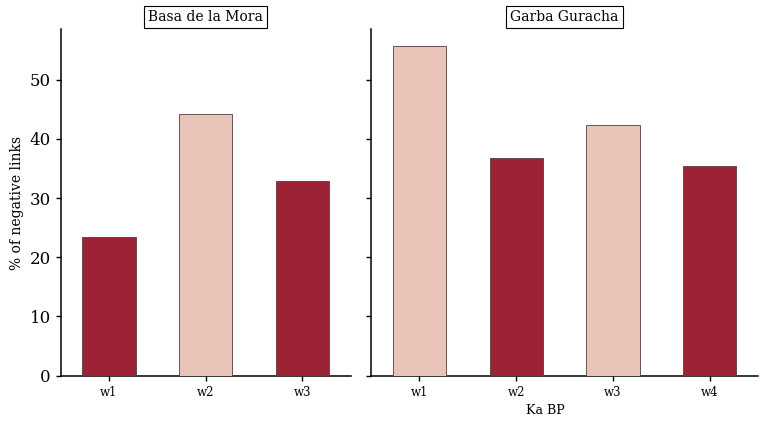

In [64]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CONFIGURACIÓN ──────────────────────────────────────────────────────────────
TIPO = ""  # cambia aquí si usas "0.5" o "0.1"

# Nombres de los ficheros y ventanas para cada sitio
BSM_WINDOWS = {
    "w1": "bsm_w1_counts_filtrado.pkl", #ambia por tus nombres reales
    "w2": "bsm_w2_counts_filtrado.pkl",
    "w3": "bsm_w3_counts_filtrado.pkl"
}

GGU_WINDOWS = {
    "w1": "gg_w1_counts_filtrado.pkl",
    "w2": "gg_w2_counts_filtrado.pkl",
    "w3": "gg_w3_counts_filtrado.pkl",
    "w4": "gg_w4_counts_filtrado.pkl",
}

MOS_WINDOWS = {
    "w1": "mos_w1_counts_filtrado.pkl",
    "w2": "mos_w2_counts_filtrado.pkl",
    "w3": "mos_w3_counts_filtrado.pkl",
    "w4": "mos_w4_counts_filtrado.pkl",
}

# Colores por régimen de fuego (mismo esquema que la línea temporal)
BSM_COLORS  = [ "#9b2335", "#e8c4b8", "#9b2335" ]        # alto, bajo, medio
GGU_COLORS  = ["#e8c4b8", "#9b2335", "#e8c4b8", "#9b2335"]  # bajo, alto, bajo, alto

# ── FUNCIÓN DE CARGA ───────────────────────────────────────────────────────────
def porcentaje_negativos(filename):
    with open(f"{filename}", "rb") as f:
        data = pickle.load(f)
    matriz_sig   = np.array(data["matriz_significancia"])
    matriz_coefs = np.array(data["matriz_coeficientes"])
    num_links = np.sum(matriz_sig != 0)
    if num_links == 0:
        return 0.0
    coefs_neg = np.sum((matriz_sig == -1) & (matriz_coefs < 0.0))
    return  coefs_neg / num_links * 100 if num_links > 0 else 0.0

# ── CARGAR DATOS ───────────────────────────────────────────────────────────────
bsm_vals = [porcentaje_negativos(f) for f in BSM_WINDOWS.values()]
#bsm_vals=[23.44, 6.6, 19, 17]
ggu_vals = [porcentaje_negativos(f) for f in GGU_WINDOWS.values()]
#ggu_vals=[21.33, 22.7, 22.3, 15]

bsm_labels = list(BSM_WINDOWS.keys())
ggu_labels = list(GGU_WINDOWS.keys())

# ── FIGURA ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 4.5),
    sharey=True,
    gridspec_kw={"width_ratios": [3, 4], "wspace": 0.06}
)

BAR_WIDTH = 0.55

for ax, vals, labels, colors, site in zip(
    axes,
    [bsm_vals, ggu_vals],
    [bsm_labels, ggu_labels],
    [BSM_COLORS, GGU_COLORS],
    ["Basa de la Mora", "Garba Guracha"]
):
    x = np.arange(len(vals))
    bars = ax.bar(x, vals, width=BAR_WIDTH, color=colors,
                  edgecolor="#5a3a3a", linewidth=0.6, zorder=3)

    # Puntos negros encima de cada barra (como en el original)
    # for xi, v in zip(x, vals):
    #     ax.plot(xi, v, "o", color="black", markersize=4, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_xlim(-0.5, len(vals) - 0.5)
    #ax.set_ylim(0, 40)
    #ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}%"))
    ax.grid(axis="y", linestyle="--", alpha=0.0, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

    # Título del sitio dentro de un recuadro (estilo original)
    ax.set_title(site, fontsize=10, fontweight="normal",
                 bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", lw=0.8))

# Etiquetas de ejes
axes[0].set_ylabel("% of negative links", fontsize=10)
#label del eje x en la esquina derecha

axes[1].set_xlabel("     Ka BP", fontsize=9,
                   ha="right", labelpad=4)

# Línea divisoria entre los dos paneles (simula la del original)
# fig.add_artist(plt.Line2D(
#     [0.365, 0.365], [0.08, 0.92],
#     transform=fig.transFigure,
#     color="black", linewidth=0.8
# ))

plt.savefig("negative_links.png",dpi=180, bbox_inches="tight", transparent=True)
#plt.savefig("/mnt/user-data/outputs/negative_links_white.png",dpi=180, bbox_inches="tight", facecolor="white")
print("Guardado.")

Guardado.


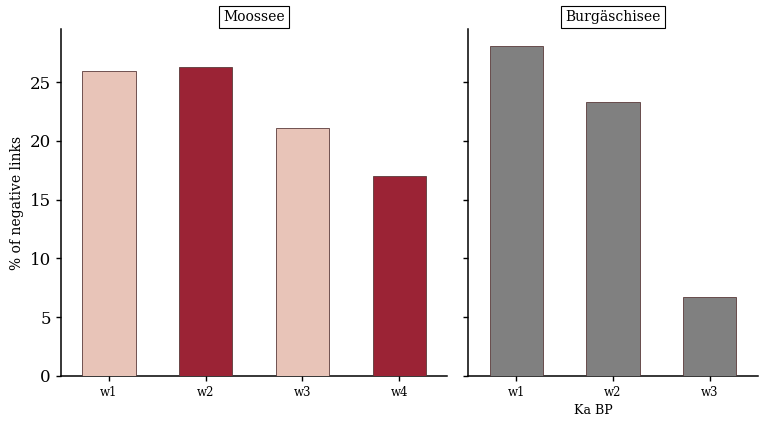

In [69]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CONFIGURACIÓN ──────────────────────────────────────────────────────────────
TIPO = ""  # cambia aquí si usas "0.5" o "0.1"

# Nombres de los ficheros y ventanas para cada sitio

MOS_WINDOWS = {
    "w1": "mos_w1_counts_filtrado.pkl",
    "w2": "mos_w2_counts_filtrado.pkl",
    "w3": "mos_w3_counts_filtrado.pkl",
    "w4": "mos_w4_filtrado.pkl",
}

BUR_WINDOWS = {
    "w1": "bur_w1_counts.pkl",
    "w2": "bur_w2_counts.pkl",
    "w3": "bur_w3_counts.pkl"
}

# Colores por régimen de fuego (mismo esquema que la línea temporal)
BUR_COLORS  = [ "grey", "gray", "gray" ]        # alto, bajo, medio
MOS_COLORS  = ["#e8c4b8", "#9b2335", "#e8c4b8", "#9b2335"]  # bajo, alto, bajo, alto

# ── FUNCIÓN DE CARGA ───────────────────────────────────────────────────────────
def porcentaje_negativos(filename):
    with open(f"{filename}", "rb") as f:
        data = pickle.load(f)
    matriz_sig   = np.array(data["matriz_significancia"])
    matriz_coefs = np.array(data["matriz_coeficientes"])
    num_links = np.sum(matriz_sig != 0)
    if num_links == 0:
        return 0.0
    coefs_neg = np.sum((matriz_sig == -1) & (matriz_coefs < 0.0))
    return  coefs_neg / num_links * 100 if num_links > 0 else 0.0

# ── CARGAR DATOS ───────────────────────────────────────────────────────────────
bsm_vals = [porcentaje_negativos(f) for f in MOS_WINDOWS.values()]
#bsm_vals=[23.44, 6.6, 19, 17]
ggu_vals = [porcentaje_negativos(f) for f in BUR_WINDOWS.values()]
#ggu_vals=[21.33, 22.7, 22.3, 15]

bsm_labels = list(MOS_WINDOWS.keys())
ggu_labels = list(BUR_WINDOWS.keys())

# ── FIGURA ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 4.5),
    sharey=True,
    gridspec_kw={"width_ratios": [4, 3], "wspace": 0.06}
)

BAR_WIDTH = 0.55

for ax, vals, labels, colors, site in zip(
    axes,
    [bsm_vals, ggu_vals],
    [bsm_labels, ggu_labels],
    [MOS_COLORS, BUR_COLORS],
    ["Moossee", "Burgäschisee"]
):
    x = np.arange(len(vals))
    bars = ax.bar(x, vals, width=BAR_WIDTH, color=colors,
                  edgecolor="#5a3a3a", linewidth=0.6, zorder=3)

    # Puntos negros encima de cada barra (como en el original)
    # for xi, v in zip(x, vals):
    #     ax.plot(xi, v, "o", color="black", markersize=4, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_xlim(-0.5, len(vals) - 0.5)
    #ax.set_ylim(0, 40)
    #ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}%"))
    ax.grid(axis="y", linestyle="--", alpha=0.0, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

    # Título del sitio dentro de un recuadro (estilo original)
    ax.set_title(site, fontsize=10, fontweight="normal",
                 bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", lw=0.8))

# Etiquetas de ejes
axes[0].set_ylabel("% of negative links", fontsize=10)
#label del eje x en la esquina derecha

axes[1].set_xlabel("     Ka BP", fontsize=9,
                   ha="right", labelpad=4)

# Línea divisoria entre los dos paneles (simula la del original)
# fig.add_artist(plt.Line2D(
#     [0.365, 0.365], [0.08, 0.92],
#     transform=fig.transFigure,
#     color="black", linewidth=0.8
# ))

plt.savefig("negative_links.png",dpi=180, bbox_inches="tight", transparent=True)
#plt.savefig("/mnt/user-data/outputs/negative_links_white.png",dpi=180, bbox_inches="tight", facecolor="white")
print("Guardado.")

In [27]:
936/60

15.6